# IND5003 Enron Project
## Contents of this Jupyter Notebook
### Dataset
Dataset from previous EDA analysis
person_of_interest_allcategories_degree.csv
person_of_interest_allcategories_betweenness.csv

# Section 0: Initialization

In [1050]:
# Import the relevant libraries 
import os # Required for directory traversal
import pandas as pd
import numpy as np
import regex as re
import string
import matplotlib.pyplot as plt

import email
from email import policy
from email.parser import BytesParser
from collections import defaultdict
from itertools import islice

import networkx as nx
import nxviz as nv

import matplotlib.pyplot as plt

import spacy

import nltk
#nltk.download()            #first timer need to download stopwords first
#nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer

import gensim
from gensim import corpora
from gensim.parsing.preprocessing import *

from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import LatentDirichletAllocation


import nltk
nltk.download('wordnet')
from wordcloud import WordCloud




[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\xantv\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Build in function for Q1

In [1051]:
# NLP - data preprocessing & cleaning

# Load spacy
nlp = spacy.load('en_core_web_sm')

def clean_string(text):

    final_string = ""

    # Make lower
    text = text.lower()

    # Remove line breaks
    # Note: that this line can be augmented and used over
    # to replace any characters with nothing or a space
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\/', ' ', text)
    #text =re.sub(r'[A-Za-z0-9]*@.*\.?[A-Za-z0-9]*', "", text)
    #text = re.sub(r'\<[^()]*\>', '', text)
    text = re.sub(r'\<.*?\>','',text)

    # Remove punctuation
    translator = str.maketrans('', '', string.punctuation)
    text = text.translate(translator)

    # Remove stop words
    text = text.split()
    useless_words = nltk.corpus.stopwords.words("english")
    useless_words = useless_words + ['forwarded','email','subject','message','forwarded','thanks']

    text_filtered = [word for word in text if not word in useless_words]

    # Remove numbers
    text_filtered = [re.sub(r'\w*\d\w*', '', w) for w in text_filtered]

    # use spacy to clean up
    text_filtered = nlp(' '.join(text_filtered))
    text_stemmed = [y.lemma_ for y in text_filtered]
    
    final_string = ' '.join(text_stemmed)

    return final_string

# Find Stop Words

def extract_stopword(text_df):
    # settings that you use for count vectorizer will go here 
    tfidf_vectorizer=TfidfVectorizer(use_idf=True) 

    # just send in all your docs here 
    tfidf_vectorizer_vectors=tfidf_vectorizer.fit_transform(text_df)

    # get the first vector out (for the first document) 
    first_vector_tfidfvectorizer=tfidf_vectorizer_vectors[0] 

    # place tf-idf values in a pandas data frame 
    df = pd.DataFrame(first_vector_tfidfvectorizer.T.todense(), index=tfidf_vectorizer.get_feature_names_out(), columns=["tfidf"])
    df.sort_values(by=["tfidf"],ascending=False,inplace=True)
    df.reset_index(inplace=True)

    adhoc_stopword = df[df['tfidf']==0]['index'].to_list()
    return adhoc_stopword

def generate_stopword(text_df):
    stop_word = set(stopwords.words('english'))
    # manually created
    stop_word.update(("to"
                    ,"cc"
                    ,"subject"
                    ,"http"
                    ,"from"
                    ,"sent"
                    ,"aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa"
                    ,'ee'
                    ,'com'
                    ,'e'
                    ,'www'
                    ,'com'
                    ,'asp'
                    ,'hotmail'
                    ,'net'
                    ,'would'
                    ,'hou'
                    ,'enron'
                    ,'ect'
                    ,'pm'
                    ,'message'
                    ,'please'
                    ,'know'
                    ,'font'
                    ,'td'
                    ,'tr'
                    ,'p'
                    ,'b'
                    ,'click'
                    ,'corp'
                    ,'time'
                    ,"mail" 
                    ,"u"
                    ,"na"
                    ,"forwarded",
                    'october',
                    'thanks',
                    'mailto',
                    'monday',
                    'let',
                    'get',
                    'image',
                    'one',
                    'said',
                    'year',
                    'need',
                    'u',
                    'x',
                    'said',
                    'type',
                    'id',
                    'date',
                    'sc',
                    'hour',
                    'ect',
                    'br',
                    'align',
                    'right',
                    'class',
                    'width',
                    'href',
                    'face',
                    'november',
                    'size',
                    'pt',
                    'arial',
                    'week',
                    'html'
                    ,'helvetica'
                    ,'may'
                    ,'enronxgate'
                    ,'a'
                    ,'b'
                    ,'c'
                    ,'d'
                    ,'e'
                    ,'f'
                    ,'g'
                    ,'h'
                    ,'i'
                    ,'j'
                    ,'k'
                    ,'l'
                    ,'m'
                    ,'n'
                    ,'o'
                    ,'p'
                    ,'q'
                    ,'r'
                    ,'s'
                    ,'t'
                    ,'u'
                    ,'v'
                    ,'w'
                    ,'x'
                    ,'y'
                    ,'z'


    ))
    # stopword from tfidf
    stop_word.update((extract_stopword(text_df)))
    return stop_word
   
#use stopword to clean text data
def clean_stopword(text, stop):
    
 
    exclude = set(string.punctuation) 
    lemma = WordNetLemmatizer()
    porter= PorterStemmer()
    
    text=text.rstrip()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    stop_free = " ".join([i for i in text.lower().split() if((i not in stop) and (not i.isdigit()))])
    punc_free = ''.join(ch for ch in stop_free if ch not in exclude)
    normalized = " ".join(lemma.lemmatize(word) for word in punc_free.split())
    #stem = " ".join(porter.stem(token) for token in normalized.split())
    
    return normalized

# lda find topic
def topic_model_v1(enron_uncleaned_emails, sample=10000, num_topics=4, eng_stopwords=''):
    analysis_df=enron_uncleaned_emails[['From', 'To', 'Date','Clean_Body2']].dropna().copy()
    sub_df=analysis_df.sample(min(sample,len(analysis_df)), random_state=42)

    text_clean=[]
    for text in sub_df['Clean_Body2']:
        text_clean.append(clean_stopword(text, eng_stopwords).split())

    dictionary = corpora.Dictionary(text_clean)
    text_term_matrix = [dictionary.doc2bow(text) for text in text_clean]

    Lda = gensim.models.ldamodel.LdaModel
    ldamodel = Lda(text_term_matrix, num_topics=num_topics, id2word = dictionary, passes=30)

    # def clean_text(text):
    #     #text = BeautifulSoup(text, 'html.parser').get_text()
    #     text = re.sub(r'[^a-zA-Z]', ' ', text)
    #     words = text.lower().split()
    #     words = [w for w in words if w not in eng_stopwords]
    #     return ' '.join(words)

    # analysis_df["clean_content"]=analysis_df.Clean_Body2.apply(clean_text)

    # wordvector = TfidfVectorizer(analyzer='word', stop_words='english', max_df=0.4, min_df=5)
    # short_analysis=analysis_df.sample( min(5000,len(analysis_df)))
    # wordvector_fit = wordvector.fit_transform(short_analysis.clean_content)
    # feature = wordvector.get_feature_names_out()

    # N = num_topics
    # clf = KMeans(n_clusters=N, 
    #             max_iter=50, 
    #             init='k-means++', 
    #             n_init=1)
    # labels = clf.fit_predict(wordvector_fit)

    # wordvector_fit_2d = wordvector_fit.todense()
    # pca = PCA(n_components=2).fit(np.asarray(wordvector_fit_2d))
    # datapoint = pca.transform(np.asarray(wordvector_fit_2d))

    return ldamodel #, datapoint,labels, clf,pca, feature, wordvector_fit

# # Feature extraction with TF-IDF
def extract_anomaly_dbss(df,column, eps,min_sample):
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(df[column].values.astype('U'))
    X_scaled = StandardScaler().fit_transform(X.toarray())
    # Apply DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_sample)  # Parameters may need tuning
    clusters = dbscan.fit_predict(X_scaled)

    # Add cluster labels to the original emails
    df['cluster'] = clusters
    df1=df[(df['cluster']==-1)]
    df2=df[(df['cluster']>-1)]
    return df1,df2


In [1052]:
# Data visualization

def plot_count_by_time(df, title):
    email_count_yearmonth= df.groupby(df['year-month'])[['Subject']].count()
    email_count_yearmonth.reset_index(inplace=True)

    # Create bar chart
    plt.figure(figsize=(35, 5))
    plt.bar(email_count_yearmonth['year-month'], email_count_yearmonth['Subject'], color='teal')

    # Add labels and title

    plt.xlabel('Year-Month')
    plt.ylabel('Email Count')
    plt.title(title)

    # Show the plot
    plt.show()

def gen_wordcloud(df_subset, stop):
    msg_strings = df_subset.values
    CUSTOM_FILTER = [lambda x: x.lower(), strip_punctuation, 
                 strip_multiple_whitespaces, strip_numeric, 
                 remove_stopwords, strip_short]
    msg_tokenized = [preprocess_string(x,CUSTOM_FILTER) for x in msg_strings]
    wn = WordNetLemmatizer()
    msg_corpus = [[wn.lemmatize(w) for w in dd ] for dd in msg_tokenized]
    text = ' '.join([word for sublist in msg_corpus for word in sublist])
    stopwords = set(stop)
    wordcloud = WordCloud(stopwords=stopwords,background_color="white", max_words=40).generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()



# Section 1: Data Extraction
- Extract the emails from the unstructured raw folder


## Email dataset

In [1053]:
cleaned_email_overall_df = pd.read_csv('enron_cleaned_emails_v2.csv')
#Preprocess email data
cleaned_email_overall_df[['day', 'date', 'month','year','time','gmt']] = cleaned_email_overall_df['Date'].str.split(' ', expand=True)
cleaned_email_overall_df['DATETIME'] = cleaned_email_overall_df['date']+'-'+cleaned_email_overall_df['month']+'-'+cleaned_email_overall_df['year']+' '+cleaned_email_overall_df['time']
cleaned_email_overall_df['DATETIME'] = pd.to_datetime(cleaned_email_overall_df['DATETIME'])
cleaned_email_overall_df['year-month'] = cleaned_email_overall_df['DATETIME'].dt.strftime('%Y-%m')
#remove dataset beyond study horizon
cleaned_email_overall_df = cleaned_email_overall_df[(cleaned_email_overall_df['DATETIME']>'1999-06-01 00:00:00')&(cleaned_email_overall_df['DATETIME']<'2002-07-01 00:00:00')]
cleaned_email_overall_df.sort_values(by='Date', ascending=True, inplace=True)
cleaned_email_overall_df.drop_duplicates(inplace=True)
cleaned_email_overall_df = cleaned_email_overall_df[~cleaned_email_overall_df['Clean_Body2'].isna()]
cleaned_email_overall_df.head()

,From,To,Date,Subject,Body,Clean_Body2,day,date,month,year,time,gmt,DATETIME,year-month
212408,david.baumbach@enron.com,eric.bass@enron.com,"Fri, 01 Dec 2000 00:00:00 -0800",NaN,What is the website for the fundamentals? Do ...,website fundamental get security access,"Fri,",01,Dec,2000,00:00:00,-0800,2000-12-01 00:00:00,2000-12
104339,richard.sanders@enron.com,sbishop@gibbs-bruns.com,"Fri, 01 Dec 2000 00:00:00 -0800",Political Issues Raised at Meeting with CPUC r...,----- Forwarded by Richard B Sanders/HOU/ECT o...,richard b sander hou ect mbd pm jame...,"Fri,",01,Dec,2000,00:00:00,-0800,2000-12-01 00:00:00,2000-12
46821,vince.kaminski@enron.com,stinson.gibner@enron.com,"Fri, 01 Dec 2000 00:00:00 -0800",Re: Compound Model for Reedy Creek,"Stinson,\n\nI think the gamma will flow into V...",stinson think gamma flow vr vince stinson gibn...,"Fri,",01,Dec,2000,00:00:00,-0800,2000-12-01 00:00:00,2000-12
104216,richard.sanders@enron.com,sbishop@gibbs-bruns.com,"Fri, 01 Dec 2000 00:00:00 -0800",FW: Generator Contact List for CPUC investigat...,----- Forwarded by Richard B Sanders/HOU/ECT o...,richard b sander hou ect houlihan terry ...,"Fri,",01,Dec,2000,00:00:00,-0800,2000-12-01 00:00:00,2000-12
330236,phillip.love@enron.com,mjillard@beaconelectric.com,"Fri, 01 Dec 2000 00:01:00 -0800",Re: ?,I will definitely pack my beanbag just in case...,definitely pack beanbag case since one willing...,"Fri,",01,Dec,2000,00:01:00,-0800,2000-12-01 00:01:00,2000-12


In [1054]:
# For drill down exploratory, we chose Within Enron - Small Recipient - POI Betweenness as sample. Similar methodology can be use for other group
pre_crisis_df = pd.read_csv('enron_pre_crisis__WithinEnron_Small_Betweenness.csv')
pre_crisis_df['To'] = pre_crisis_df['To'].map(lambda x: x.lstrip('[]/').rstrip('[]/')).replace('\'', '', regex=True)
pre_crisis_df.sort_values(by='Date', ascending=True, inplace=True)

#cleanup email body
pre_crisis_df['Clean_Body2'] = pre_crisis_df['Body'].apply(clean_string)

print(pre_crisis_df.shape)

(20361, 14)


In [1055]:
during_crisis_df = pd.read_csv('enron_during_crisis_WithinEnron_Small_Betweenness.csv')
during_crisis_df['To'] = during_crisis_df['To'].map(lambda x: x.lstrip('[]/').rstrip('[]/')).replace('\'', '', regex=True)
during_crisis_df.sort_values(by='Date', ascending=True, inplace=True)

#cleanup email body
during_crisis_df['Clean_Body2'] = during_crisis_df['Body'].apply(clean_string)

print(during_crisis_df.shape)

(56650, 14)


In [1056]:
post_crisis_df = pd.read_csv('enron_post_crisis_WithinEnron_Small_Betweenness.csv')
post_crisis_df['To'] = post_crisis_df['To'].map(lambda x: x.lstrip('[]/').rstrip('[]/')).replace('\'', '', regex=True)
post_crisis_df.sort_values(by='Date', ascending=True, inplace=True)

#cleanup email body
post_crisis_df['Clean_Body2'] = post_crisis_df['Body'].apply(clean_string)

print(post_crisis_df.shape)

(14893, 14)


## POI

In [1057]:
poi_degree = pd.read_csv('person_of_interest_allcategories_degree.csv')
poi_betweenness = pd.read_csv('person_of_interest_allcategories_betweenness.csv')

In [1058]:
poi_betweenness

,Unnamed: 0,From External - Large,To External - Large,Within Enron - Small,Within Enron - Large,All_Data,PERIOD,Rank
0,0,ewo@jmbm.com,ewo@jmbm.com,tana.jones@enron.com,mark.taylor@enron.com,susan.scott@enron.com,Pre_crisis,1
1,1,gsullivan@sempra.com,gsullivan@sempra.com,sally.beck@enron.com,sally.beck@enron.com,tana.jones@enron.com,Pre_crisis,2
2,2,mday@gmssr.com,mday@gmssr.com,mark.taylor@enron.com,tana.jones@enron.com,gerald.nemec@enron.com,Pre_crisis,3
3,3,bcherry@sempra.com,bcherry@sempra.com,sara.shackleton@enron.com,scott.mills@enron.com,gsullivan@sempra.com,Pre_crisis,4
4,4,craigc@calpine.com,craigc@calpine.com,vince.kaminski@enron.com,dale.neuner@enron.com,daren.farmer@enron.com,Pre_crisis,5
5,5,marcel@turn.org,marcel@turn.org,susan.scott@enron.com,lisa.cousino@enron.com,mark.taylor@enron.com,Pre_crisis,6
6,6,chj@aelaw.com,susan.scott@enron.com,david.delainey@enron.com,russell.diamond@enron.com,sally.beck@enron.com,Pre_crisis,7
7,7,bmcmills@duke-energy.com,chj@aelaw.com,benjamin.rogers@enron.com,marilyn.colbert@enron.com,russell.diamond@enron.com,Pre_crisis,8
8,8,mjones7@txu.com,sarah.novosel@enron.com,daren.farmer@enron.com,taffy.milligan@enron.com,sara.shackleton@enron.com,Pre_crisis,9
9,9,johnj@bcjlaw.com,eric.bass@enron.com,steven.kean@enron.com,veronica.espinoza@enron.com,taffy.milligan@enron.com,Pre_crisis,10


In [1059]:
poi_degree

,Unnamed: 0,From External - Large,To External - Large,Within Enron - Small,Within Enron - Large,All_Data,PERIOD,Rank
0,0,pierce@haas.berkeley.edu,pierce@haas.berkeley.edu,tana.jones@enron.com,marilyn.colbert@enron.com,tana.jones@enron.com,Pre_crisis,1
1,1,leonard@haas.berkeley.edu,leonard@haas.berkeley.edu,sara.shackleton@enron.com,cheryl.johnson@enron.com,mark.taylor@enron.com,Pre_crisis,2
2,2,gsullivan@sempra.com,gsullivan@sempra.com,mark.taylor@enron.com,veronica.espinoza@enron.com,marilyn.colbert@enron.com,Pre_crisis,3
3,3,rjl9@pge.com,rjl9@pge.com,chris.germany@enron.com,russell.diamond@enron.com,gsullivan@sempra.com,Pre_crisis,4
4,4,marcel@turn.org,marcel@turn.org,daren.farmer@enron.com,tana.jones@enron.com,cheryl.johnson@enron.com,Pre_crisis,5
5,5,ewo@jmbm.com,ewo@jmbm.com,vince.kaminski@enron.com,taffy.milligan@enron.com,veronica.espinoza@enron.com,Pre_crisis,6
6,6,chj@aelaw.com,chj@aelaw.com,carol.clair@enron.com,linda.noske@enron.com,marcel@turn.org,Pre_crisis,7
7,7,jblackwell@luce.com,jblackwell@luce.com,benjamin.rogers@enron.com,janette.elbertson@enron.com,taffy.milligan@enron.com,Pre_crisis,8
8,8,al2@jmbm.com,al2@jmbm.com,gerald.nemec@enron.com,dina.snow@enron.com,russell.diamond@enron.com,Pre_crisis,9
9,9,mark.c.moench@williams.com,mark.c.moench@williams.com,sally.beck@enron.com,deb.korkmas@enron.com,sara.shackleton@enron.com,Pre_crisis,10


# Section 2 : Overall Topic

### Finding 1: Possibility of incomplete dataset

In [1060]:
TOP_EXECUTIVE = ('kenneth.lay@enron.com','ken.lay-@enron.com','ken.lay@enron.com','jeff.skilling@enron.com','andrew.fastow@enron.com')
top_executive_email = cleaned_email_overall_df[cleaned_email_overall_df['From'].isin(TOP_EXECUTIVE)]
top_executive_email[['From','To']].groupby(['From']).count()

,To
From,
andrew.fastow@enron.com,8
jeff.skilling@enron.com,66
ken.lay-@enron.com,2
ken.lay@enron.com,2
kenneth.lay@enron.com,22


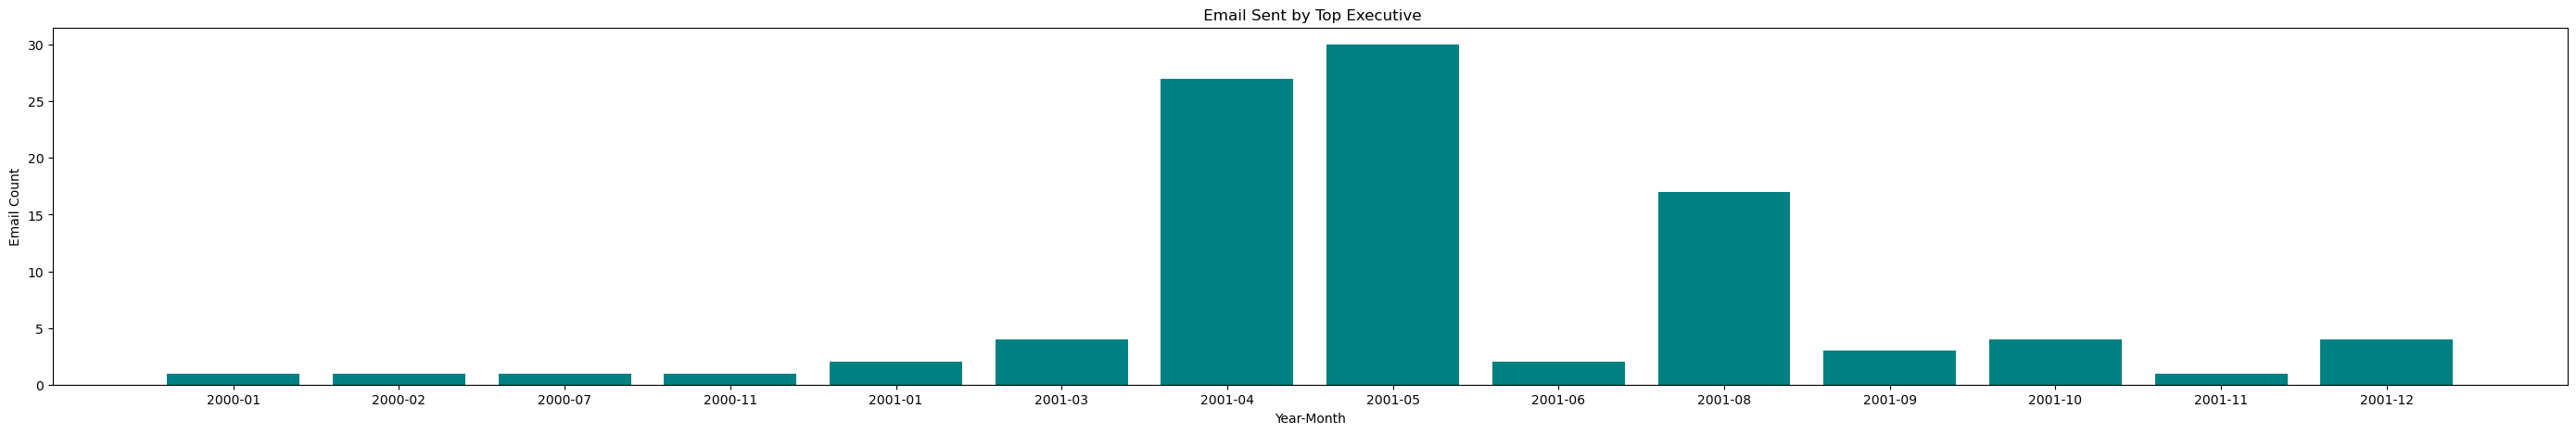

In [1061]:
#email send across time show suddent drop on 2001-06
plot_count_by_time(top_executive_email,' Email Sent by Top Executive')

## LDA & Wordcloud for overall Topic across 3 different time horizon

In [1062]:
# Getting stopword specific to respective time horizon
pre_crisis_stopword = generate_stopword(pre_crisis_df['Clean_Body2'])
during_crisis_stopword = generate_stopword(during_crisis_df['Clean_Body2'])
post_crisis_stopword = generate_stopword(post_crisis_df['Clean_Body2'])

# LDA Topic Analysis
pre_crisis_lda = topic_model_v1(pre_crisis_df, sample=10000, num_topics=4, eng_stopwords=pre_crisis_stopword)
during_crisis_lda = topic_model_v1(during_crisis_df, sample=10000, num_topics=4, eng_stopwords=during_crisis_stopword)
post_crisis_lda = topic_model_v1(post_crisis_df, sample=10000, num_topics=4, eng_stopwords=post_crisis_stopword)

### Finding 2: Topic for Within Enron - Small Recipient - POI Betweenness also do change over time

#### Pre Crisis

In [1063]:
#Pre Crisis
pre_crisis_topic = ''
for idx, topic in pre_crisis_lda.show_topics(formatted=False, num_words=10):
    print('Topic: {} \nWords: {}'.format(idx, ','.join([w[0] for w in topic])))
    pre_crisis_topic = pre_crisis_topic +','.join([w[0] for w in topic])

Topic: 0 
Words: attach,change,review,comment,draft,legal,version,final,forward,point
Topic: 1 
Words: work,think,group,contact,next,meeting,schedule,two,forward,still
Topic: 2 
Words: price,david,trade,jones,june,bob,capital,legal,wholesale,stephanie
Topic: 3 
Words: agreement,meeting,steve,elizabeth,james,jeff,schedule,sager,brian,legal


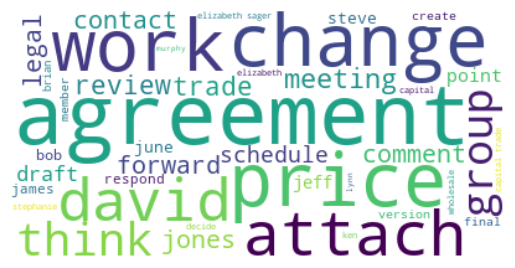

In [1064]:
gen_wordcloud(pre_crisis_df['Clean_Body2'], pre_crisis_stopword)

#### During Crisis

In [1065]:
#Pre Crisis
during_crisis_topic = ''
for idx, topic in during_crisis_lda.show_topics(formatted=False, num_words=10):
    print('Topic: {} \nWords: {}'.format(idx, ','.join([w[0] for w in topic])))
    during_crisis_topic = during_crisis_topic +','.join([w[0] for w in topic])

Topic: 0 
Words: send,like,want,well,could,today,take,information,use,group
Topic: 1 
Words: power,market,commission,new,could,customer,take,use,month,order
Topic: 2 
Words: service,business,trading,information,member,provide,inc,access,new,customer
Topic: 3 
Words: change,credit,term,order,new,approval,approve,bank,include,receive


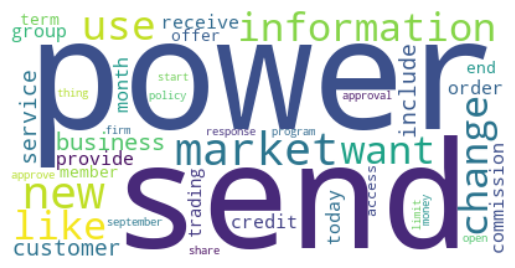

In [1066]:
gen_wordcloud(during_crisis_df['Clean_Body2'], during_crisis_stopword)

#### Post Crisis

In [1067]:
#Pre Crisis
post_crisis_topic = ''
for idx, topic in post_crisis_lda.show_topics(formatted=False, num_words=10):
    print('Topic: {} \nWords: {}'.format(idx, ','.join([w[0] for w in topic])))
    post_crisis_topic = post_crisis_topic +','.join([w[0] for w in topic])

Topic: 0 
Words: report,publish,view,available,name,website,emw
Topic: 1 
Words: view,website,emw,publish,available,name,report
Topic: 2 
Words: available,publish,view,website,name,report,emw
Topic: 3 
Words: name,website,publish,emw,report,view,available


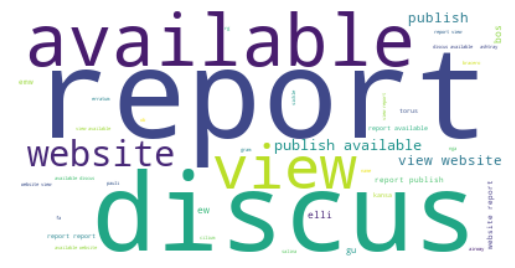

In [1068]:
gen_wordcloud(post_crisis_df['Clean_Body2'], post_crisis_stopword)

### Finding 3: Looking at community - POI, we can roughly estimate their scope of work. the behaviour of each community topic also show it varied across time

#### Pre Crisis

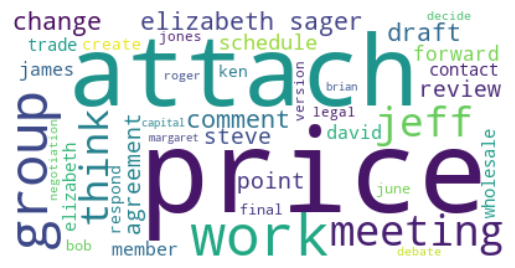

['elizabeth.sager@enron.com' 'maureen.mcvicker@enron.com'
 'steven.kean@enron.com' 'jeff.dasovich@enron.com']


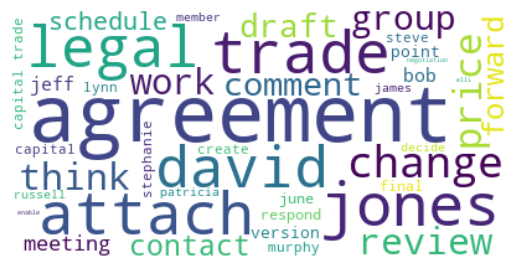

['sara.shackleton@enron.com' 'mark.taylor@enron.com'
 'tana.jones@enron.com' 'ted.murphy@enron.com']


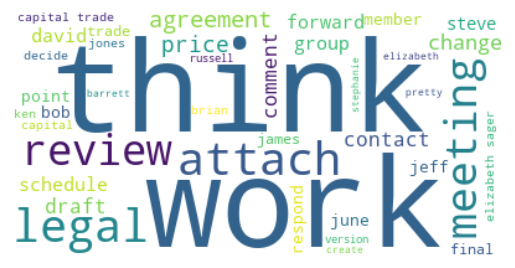

['richard.sanders@enron.com' 'mark.haedicke@enron.com']


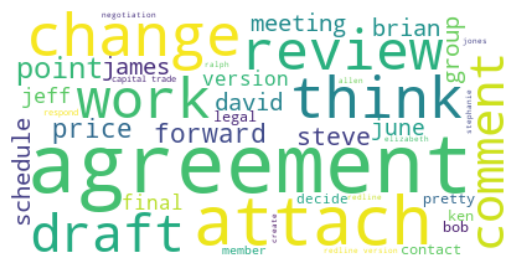

['gerald.nemec@enron.com' 'susan.scott@enron.com'
 'tobin.carlson@enron.com']


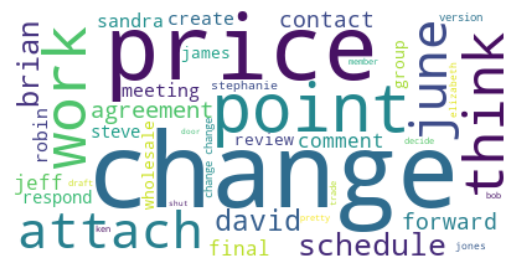

['chris.germany@enron.com']


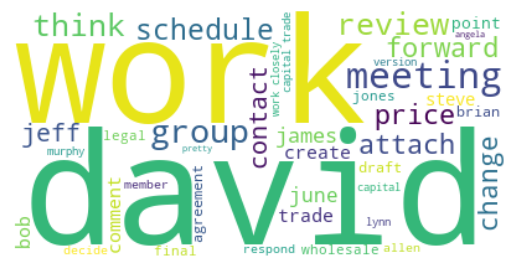

['john.lavorato@enron.com' 'sally.beck@enron.com'
 'david.delainey@enron.com']


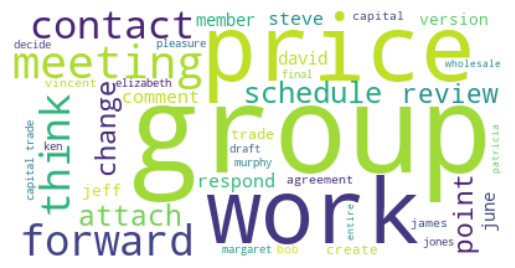

['vince.kaminski@enron.com']


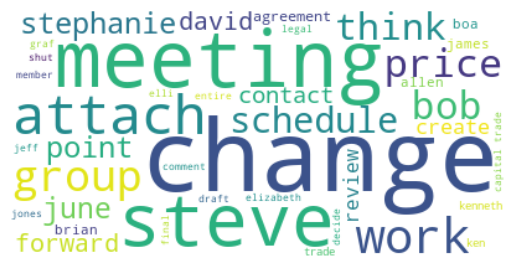

['daren.farmer@enron.com']


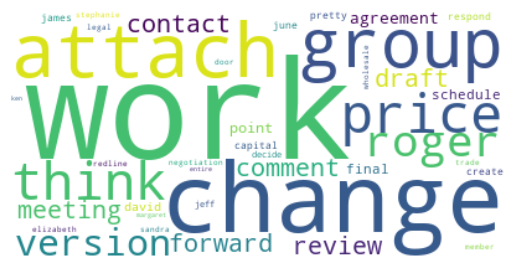

['benjamin.rogers@enron.com']


In [1069]:
# Using topic highlighted in each time horizon as stopword to allow more community-specif topic to emerge

pre_crisis_stopword.update(pre_crisis_topic)

for community in pre_crisis_df['Community'].unique():
    part_df = pre_crisis_df[pre_crisis_df['Community']==community]
    gen_wordcloud(part_df['Clean_Body2'], pre_crisis_stopword)
    print(part_df[part_df['From'].isin(poi_betweenness[poi_betweenness['PERIOD']=='Pre_crisis']['Within Enron - Small'].values)]['From'].unique())

#### During Crisis

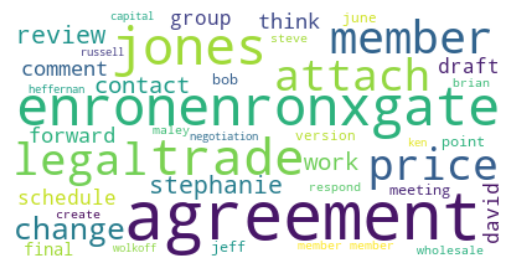

['sara.shackleton@enron.com' 'tana.jones@enron.com'
 'mark.taylor@enron.com']


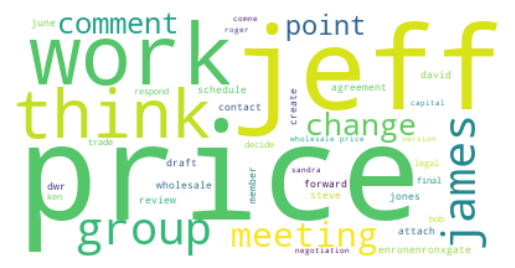

['steven.kean@enron.com' 'jeff.dasovich@enron.com' 'd..steffes@enron.com']


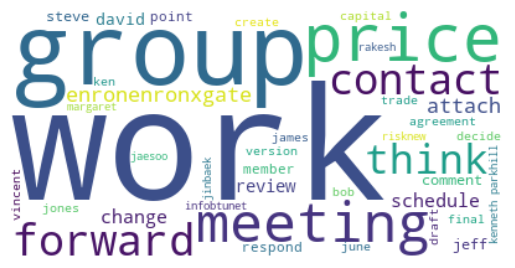

['vince.kaminski@enron.com']


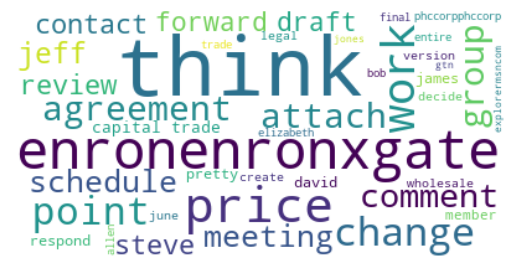

['susan.scott@enron.com']


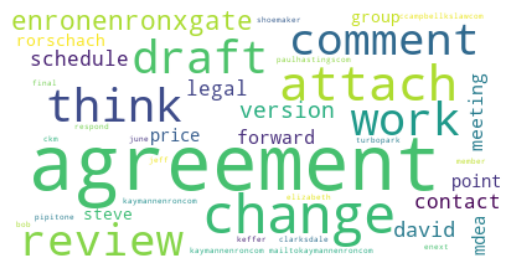

['kay.mann@enron.com']


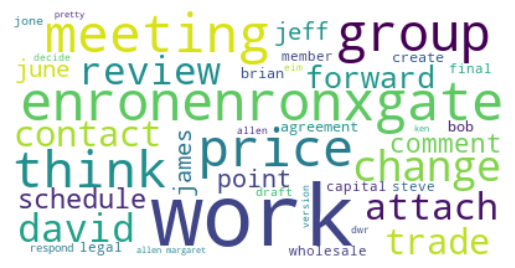

['sally.beck@enron.com' 'john.arnold@enron.com' 'john.lavorato@enron.com'
 'louise.kitchen@enron.com']


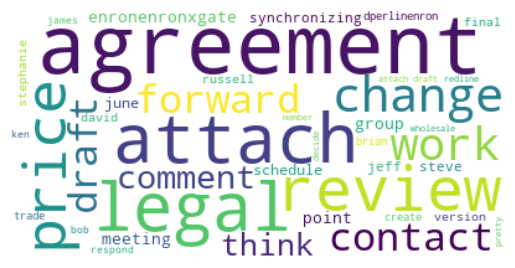

['debra.perlingiere@enron.com' 'gerald.nemec@enron.com'
 'chris.foster@enron.com' 'dan.hyvl@enron.com' 'barry.tycholiz@enron.com']


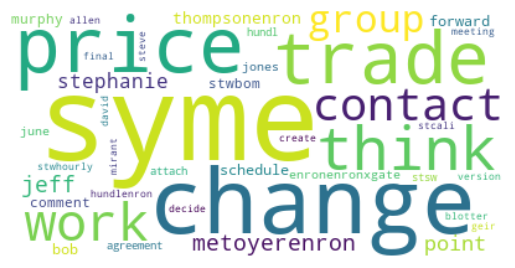

['kate.symes@enron.com']


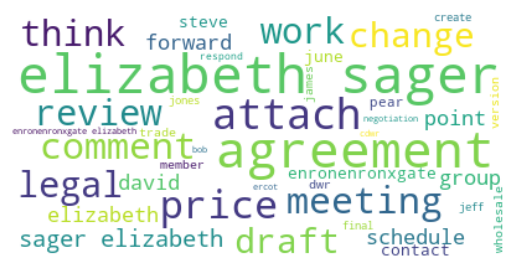

['elizabeth.sager@enron.com']


In [1070]:
# Using topic highlighted in each time horizon as stopword to allow more community-specif topic to emerge

during_crisis_stopword.update(during_crisis_topic)

for community in during_crisis_df['Community'].unique():
    part_df = during_crisis_df[during_crisis_df['Community']==community]
    gen_wordcloud(part_df['Clean_Body2'], pre_crisis_stopword)
    print(part_df[part_df['From'].isin(poi_betweenness[poi_betweenness['PERIOD']=='During_crisis']['Within Enron - Small'].values)]['From'].unique())

#### Post Crisis

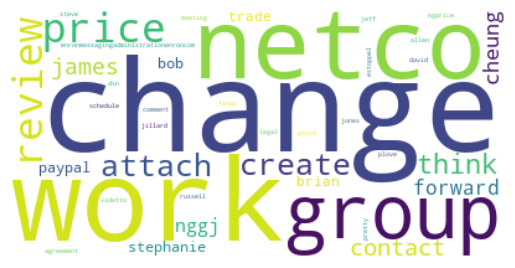

['m..love@enron.com' 'kam.keiser@enron.com']


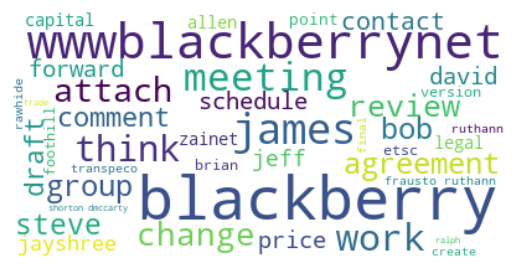

['rod.hayslett@enron.com' 'a..howard@enron.com' 'john.keiser@enron.com']


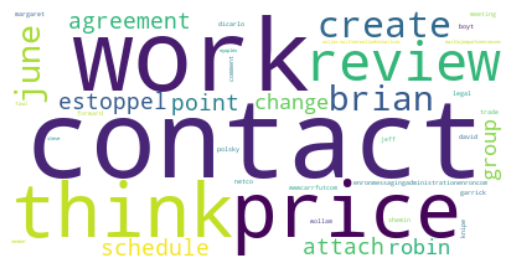

['chris.germany@enron.com' 'joe.parks@enron.com' 'frank.hayden@enron.com']


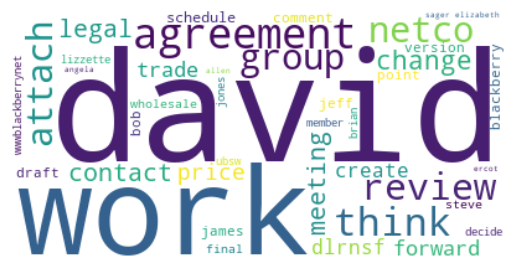

['m..presto@enron.com' 'michelle.cash@enron.com'
 'louise.kitchen@enron.com' 'amy.fitzpatrick@enron.com'
 'john.lavorato@enron.com']


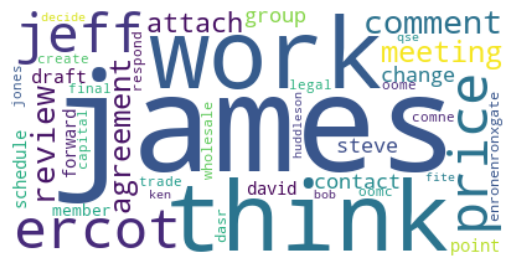

['d..steffes@enron.com' 'l..nicolay@enron.com']


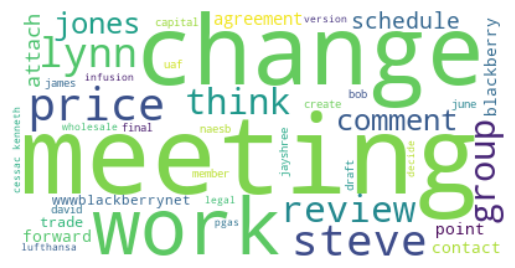

['shelley.corman@enron.com']


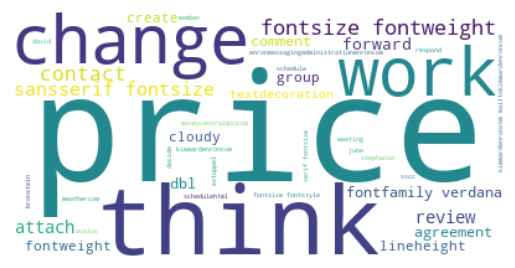

['houston <.ward@enron.com>']


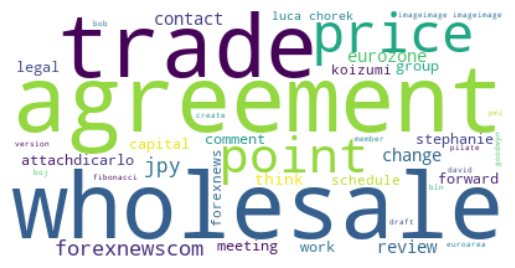

['sara.shackleton@enron.com']


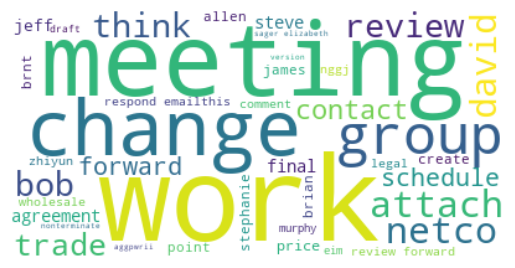

['sally.beck@enron.com' 'w..white@enron.com']


In [1071]:
# Using topic highlighted in each time horizon as stopword to allow more community-specif topic to emerge

post_crisis_stopword.update(post_crisis_topic)

for community in post_crisis_df['Community'].unique():
    part_df = post_crisis_df[post_crisis_df['Community']==community]
    gen_wordcloud(part_df['Clean_Body2'], pre_crisis_stopword)
    print(part_df[part_df['From'].isin(poi_betweenness[poi_betweenness['PERIOD']=='Post_crisis']['Within Enron - Small'].values)]['From'].unique())

# Section 3 Drill Down analysis to specific community / POI / Topic to perform anomaly detection

## Case1: vince.kaminski@enron.com

In [1072]:
study_case_1_from = 'vince.kaminski@enron.com'
part_df = cleaned_email_overall_df[(cleaned_email_overall_df['From']==study_case_1_from)&(cleaned_email_overall_df['Clean_Body2']!='')]
part_df.reset_index(inplace=True, drop=True)

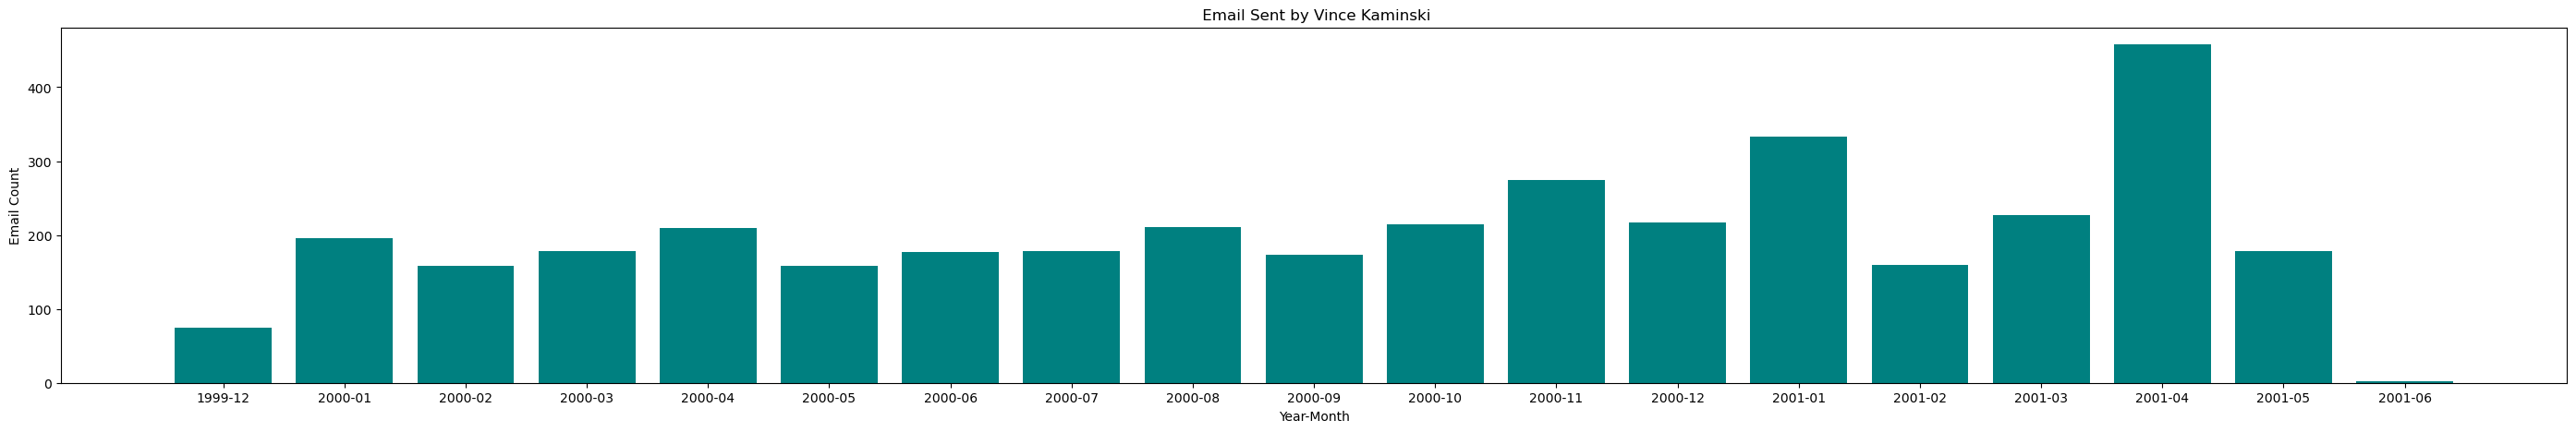

In [1073]:
#email send across time show suddent drop on 2001-06
plot_count_by_time(part_df,' Email Sent by Vince Kaminski')

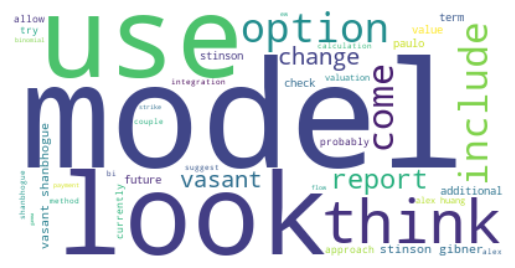

In [1074]:
vince_kaminski_stopword = generate_stopword(part_df['Clean_Body2'].values.astype('U'))
vince_kaminski_stopword.update(('ectect','enronenron', 'vince', 'kaminski'))
gen_wordcloud(part_df[(part_df['year-month']=='2001-05')|(part_df['year-month']=='2001-04')]['Clean_Body2'], vince_kaminski_stopword)

In [1075]:
part_df[(part_df['year-month']=='2001-05')|(part_df['year-month']=='2001-04')][['From','To']].groupby(['To']).count().reset_index().sort_values(by='From', ascending=False).head(10)

,To,From
127,vkaminski@aol.com,203
107,shirley.crenshaw@enron.com,48
113,stinson.gibner@enron.com,27
123,vasant.shanbhogue@enron.com,20
89,molly.magee@enron.com,15
16,christie.patrick@enron.com,14
13,castro@rice.edu,12
5,anita.dupont@enron.com,11
6,anne.labbe@enron.com,10
42,iris.mack@enron.com,9


In [1076]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from matplotlib import pyplot as plt

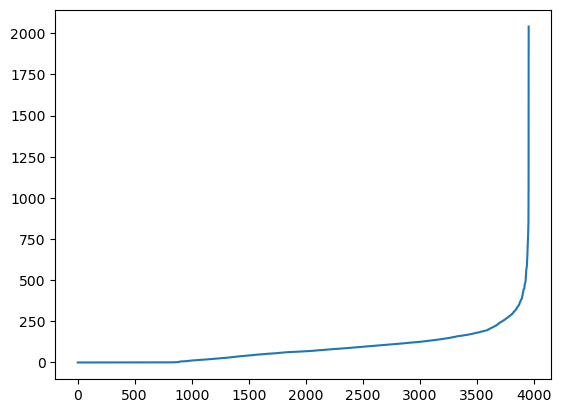

In [1077]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(part_df['Clean_Body2'].values.astype('U'))
X_scaled = StandardScaler().fit_transform(X.toarray())
neighbors = NearestNeighbors(n_neighbors=20)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

In [1078]:
df1,df2 = extract_anomaly_dbss(part_df[part_df['Clean_Body2'].str.contains('model')],'Clean_Body2',200,int(len(part_df)*0.1))
print(df1.shape)
print(df2.shape)

(7, 15)
(458, 15)


In [1079]:
df1.to_csv("dbss_result_vincekaminski.csv", index=False)

In [1080]:
df2.to_csv("dbss_result_vincekaminski2.csv", index=False)

## Case2: susan.scott@enron.com

In [1081]:
study_case_2_from = 'susan.scott@enron.com'
part_df = cleaned_email_overall_df[(cleaned_email_overall_df['From']==study_case_2_from)&(cleaned_email_overall_df['Clean_Body2']!='')]
part_df.reset_index(inplace=True, drop=True)

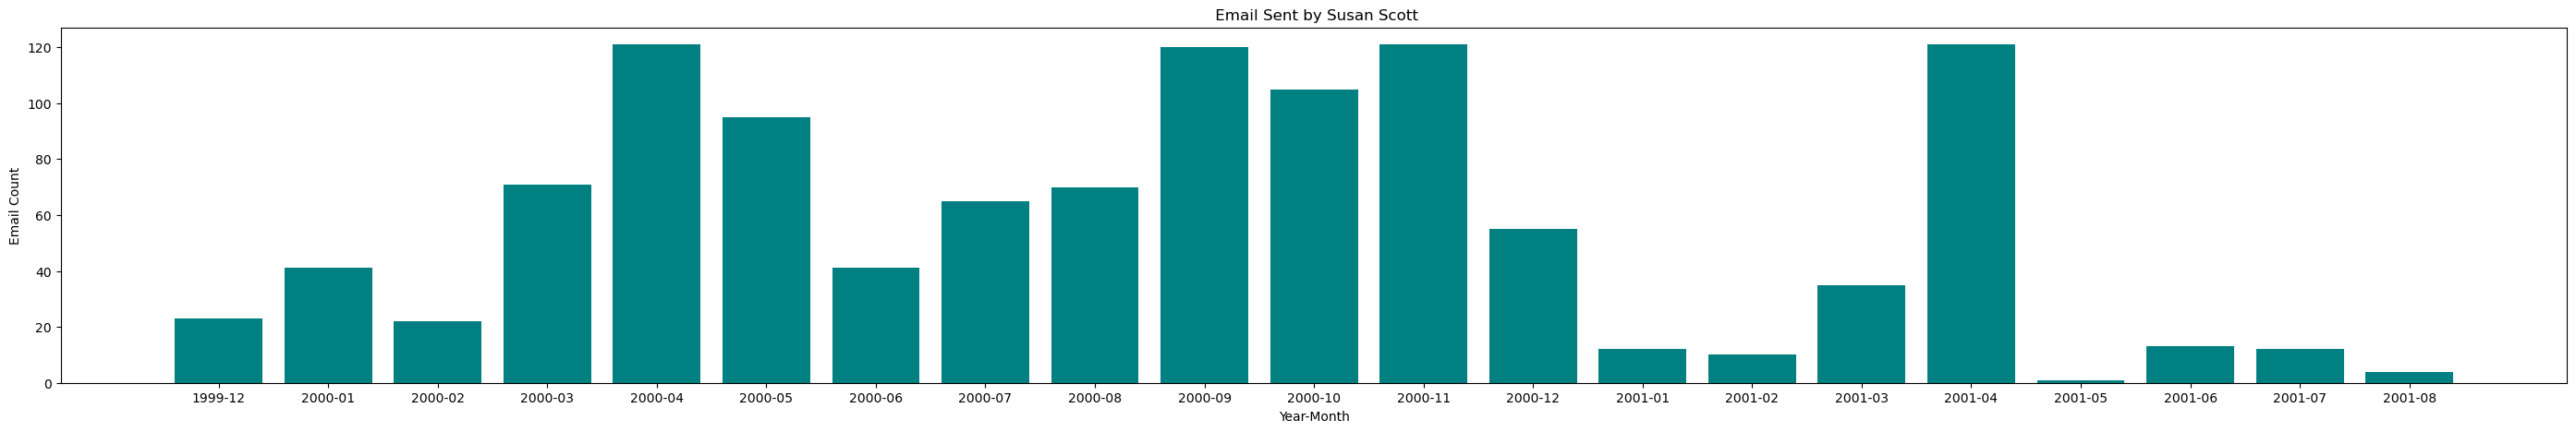

In [1082]:
#email send across time show suddent drop on 2001-06
plot_count_by_time(part_df,' Email Sent by Susan Scott')

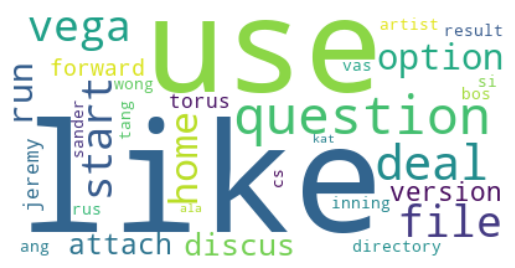

In [1083]:
susan_scott_stopword = generate_stopword(part_df['Clean_Body2'].values.astype('U'))
susan_scott_stopword.update(('ectect','susan', 'scott'))
gen_wordcloud(part_df[(part_df['year-month']=='2001-04')]['Clean_Body2'], susan_scott_stopword)

In [1084]:
part_df[(part_df['year-month']=='2001-04')][['From','To']].groupby(['To']).count().reset_index().sort_values(by='From', ascending=False).head(10)

,To,From
19,julieg@qualcomm.com,13
11,ehillegeist@hotmail.com,12
3,celeahy@hotmail.com,8
4,christi.nicolay@enron.com,7
31,lisa.gillette@enron.com,7
18,jkbowles@hotmail.com,6
52,tobin.carlson@enron.com,4
36,mharp@austin.apc.slb.com,3
6,darren.maloney@enron.com,3
49,susan.scott@enron.com,3


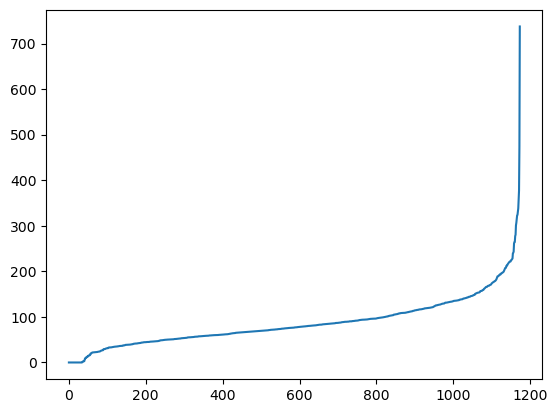

In [1085]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(part_df['Clean_Body2'].values.astype('U'))
X_scaled = StandardScaler().fit_transform(X.toarray())
neighbors = NearestNeighbors(n_neighbors=20)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

In [1086]:
df1,df2 = extract_anomaly_dbss(part_df,'Clean_Body2',200,10)
print(df1.shape)
print(df2.shape)

(60, 15)
(1114, 15)


In [1087]:
df1.to_csv('dbss_result_susan_external.csv', index=False)

## Case3: sara.shackleton@enron.com

In [1088]:
study_case_3_from = 'sara.shackleton@enron.com'
part_df = cleaned_email_overall_df[(cleaned_email_overall_df['From']==study_case_3_from)&(cleaned_email_overall_df['Clean_Body2']!='')]
part_df.reset_index(inplace=True, drop=True)

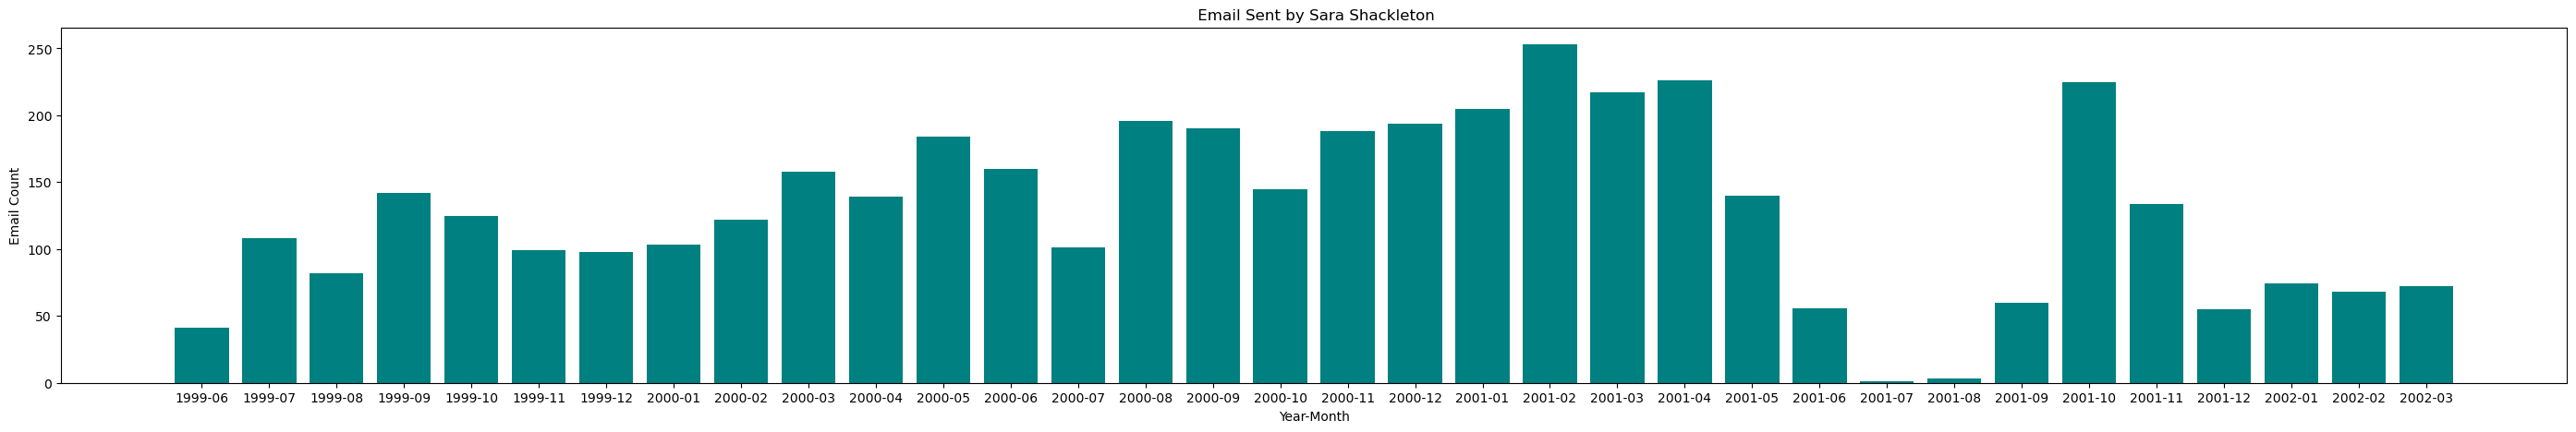

In [1089]:
#email send across time show suddent drop on 2001-06
plot_count_by_time(part_df,' Email Sent by Sara Shackleton')

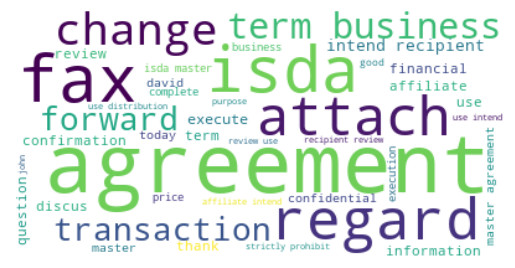

In [1090]:
sara_shackleton_stopword = generate_stopword(part_df['Clean_Body2'].values.astype('U'))
sara_shackleton_stopword.update(('sara','shackleton'))
gen_wordcloud(part_df[(part_df['year-month']=='2001-10')]['Clean_Body2'], sara_shackleton_stopword)

In [1091]:
part_df[(part_df['year-month']=='2001-10')][['From','To']].groupby(['To']).count().reset_index().sort_values(by='From', ascending=False).head(10)

,To,From
35,joanne.rozycki@enron.com,20
79,sshackl@swbell.net,15
55,marie.heard@enron.com,13
47,legal <.taylor@enron.com>,10
77,sheila.glover@enron.com,9
90,tom.doukas@enron.com,8
88,tanya.rohauer@enron.com,6
28,houston <.ward@enron.com>,6
84,susan.bailey@enron.com,5
81,stephanie.panus@enron.com,4


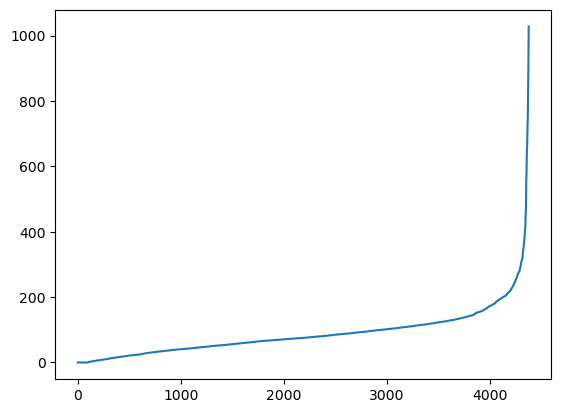

In [1092]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(part_df['Clean_Body2'].values.astype('U'))
X_scaled = StandardScaler().fit_transform(X.toarray())
neighbors = NearestNeighbors(n_neighbors=20)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.plot(distances)

In [1093]:
df1,df2 = extract_anomaly_dbss(part_df[part_df['Clean_Body2'].str.contains('agreement')],'Clean_Body2',200,10)
print(df1.shape)
print(df2.shape)

(21, 15)
(1284, 15)


In [1095]:
df1.to_csv('dbss_result_sara_shackleton.csv', index=False)

## Case4: shelley.corman@enron.com

In [1096]:
study_case_4_from = 'shelley.corman@enron.com'
part_df = cleaned_email_overall_df[(cleaned_email_overall_df['From']==study_case_4_from)&(cleaned_email_overall_df['Clean_Body2']!='')]
part_df.reset_index(inplace=True, drop=True)

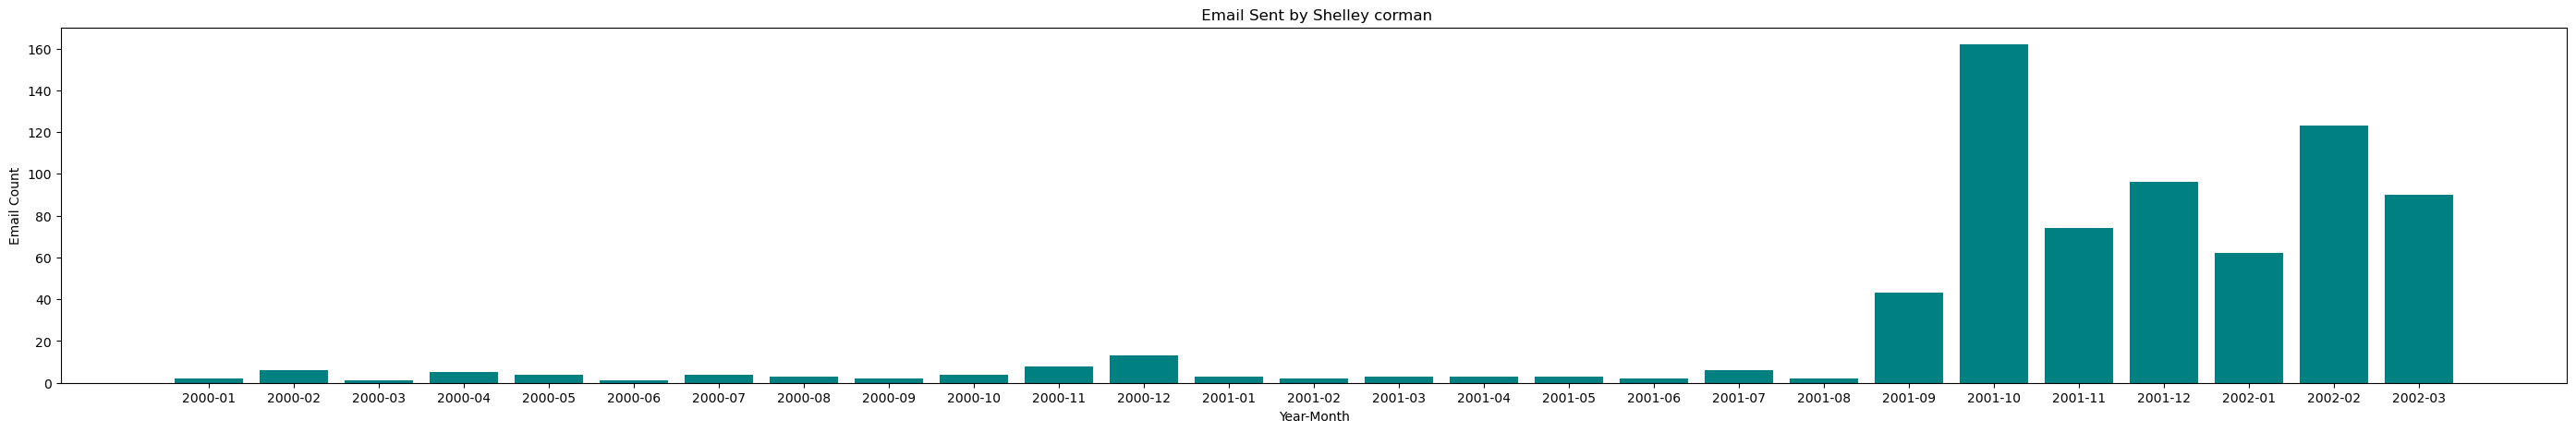

In [1097]:
#email send across time show suddent drop on 2001-06
plot_count_by_time(part_df,' Email Sent by Shelley corman')

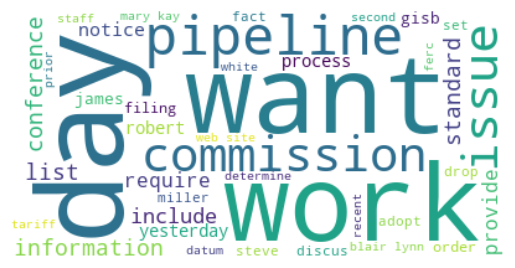

In [1098]:
shelley_corman_stopword = generate_stopword(part_df['Clean_Body2'].values.astype('U'))
shelley_corman_stopword.update(('shelley','corman'))
gen_wordcloud(part_df[(part_df['year-month']=='2001-10')]['Clean_Body2'], shelley_corman_stopword)